# Partie II : CNN pour Classification d'Images
## Dataset : Fashion-MNIST

Ce notebook implémente un CNN complet pour la classification d'images de vêtements, avec une analyse théorique et expérimentale détaillée.

## Table des matières

1. [Importation des bibliothèques](#1-importation-des-bibliothèques)
2. [Chargement et analyse du dataset](#2-chargement-et-analyse-du-dataset)
3. [Calculs manuels de convolution et pooling](#3-calculs-manuels-de-convolution-et-pooling)
4. [Implémentation manuelle](#4-implémentation-manuelle)
5. [Comparaison avec nn.Conv2d et nn.MaxPool2d](#5-comparaison-avec-nnconv2d-et-nnmaxpool2d)
6. [Construction d'un CNN inspiré de LeNet](#6-construction-dun-cnn-inspiré-de-lenet)
7. [Étude expérimentale des hyperparamètres](#7-étude-expérimentale-des-hyperparamètres)
8. [Visualisation des feature maps et filtres](#8-visualisation-des-feature-maps-et-filtres)
9. [Comparaison MLP vs CNN](#9-comparaison-mlp-vs-cnn)
10. [Évaluation du modèle](#10-évaluation-du-modèle)
11. [Analyse critique détaillée](#11-analyse-critique-détaillée)
12. [Réponse à la question de synthèse](#12-réponse-à-la-question-de-synthèse)

## 1. Importation des bibliothèques

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configuration pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Configuration des plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Vérification du GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")

Device utilisé : cpu


## 2. Chargement et analyse du dataset

In [28]:
# Définition des transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalisation [-1, 1]
])

# Chargement du dataset Fashion-MNIST
train_dataset_full = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Division train/validation
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(train_dataset_full, [train_size, val_size], generator=torch.Generator().manual_seed(42))

print(f"=== Informations sur le dataset ===")
print(f"Taille de l'image : {train_dataset_full[0][0].shape}")
print(f"Train : {len(train_dataset)} échantillons")
print(f"Validation : {len(val_dataset)} échantillons")
print(f"Test : {len(test_dataset)} échantillons")

=== Informations sur le dataset ===
Taille de l'image : torch.Size([1, 28, 28])
Train : 48000 échantillons
Validation : 12000 échantillons
Test : 10000 échantillons


In [29]:
# Noms des classes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("=== Classes du dataset ===")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

=== Classes du dataset ===
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


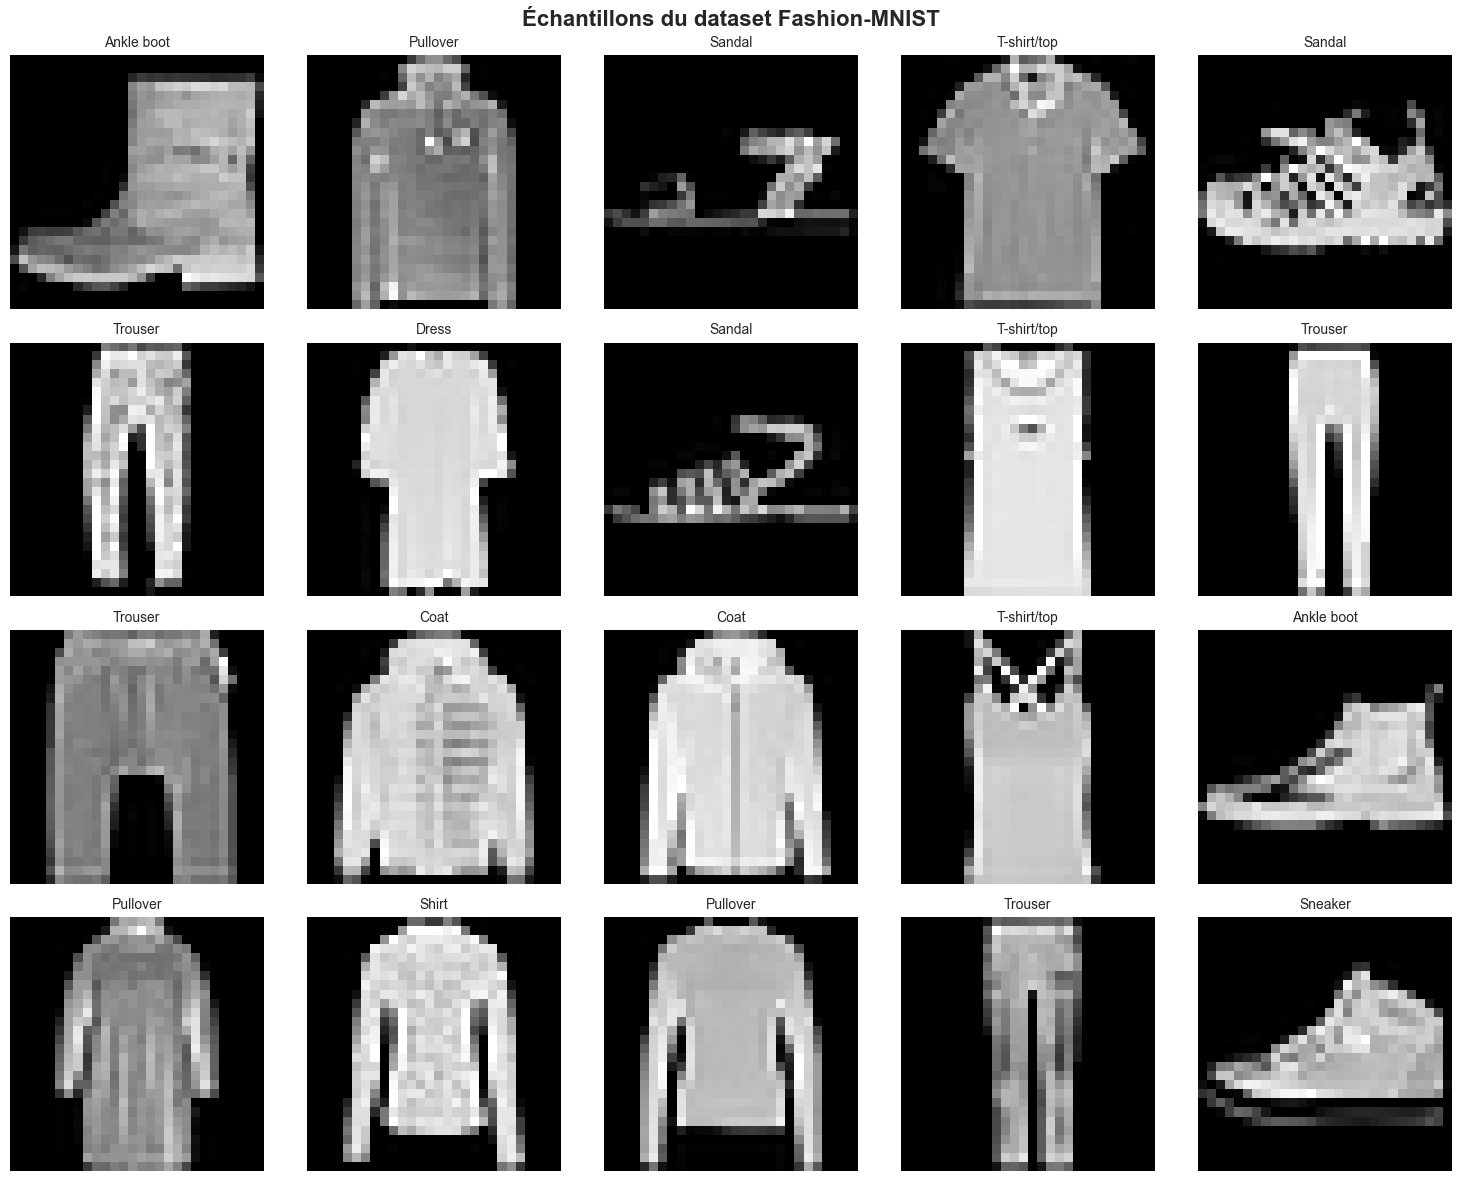

In [30]:
# Visualisation d'échantillons
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i in range(20):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'{class_names[label]}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Échantillons du dataset Fashion-MNIST', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fashion_mnist_samples.png', dpi=300, bbox_inches='tight')
plt.show()

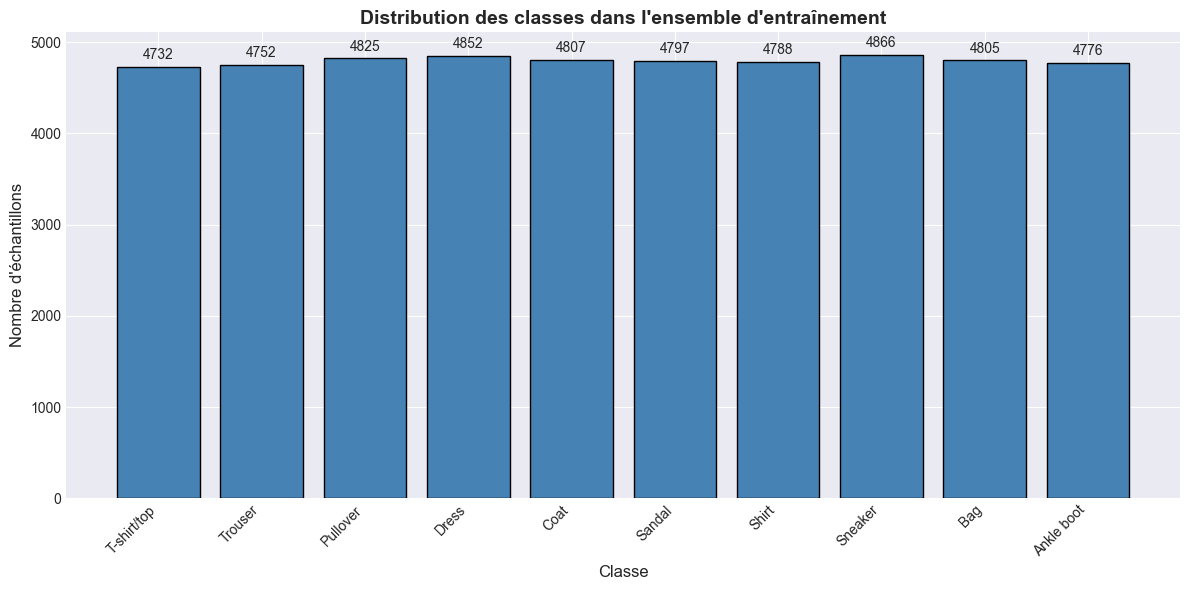

In [31]:
# Distribution des classes
train_labels = [label for _, label in train_dataset]
class_counts = np.bincount(train_labels)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(class_names)), class_counts, color='steelblue', edgecolor='black')
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Nombre d\'échantillons', fontsize=12)
ax.set_title('Distribution des classes dans l\'ensemble d\'entraînement', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')

# Ajout des valeurs sur les barres
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(count),
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# Création des DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"=== DataLoaders créés ===")
print(f"Batch size : {batch_size}")
print(f"Nombre de batches (train) : {len(train_loader)}")
print(f"Nombre de batches (val) : {len(val_loader)}")
print(f"Nombre de batches (test) : {len(test_loader)}")

=== DataLoaders créés ===
Batch size : 64
Nombre de batches (train) : 750
Nombre de batches (val) : 188
Nombre de batches (test) : 157


## 3. Calculs manuels de convolution et pooling

In [33]:
# Exemple de convolution manuelle
def manual_conv2d(input_tensor, kernel, stride=1, padding=0):
    """
    Implémentation manuelle de la convolution 2D.
    
    Args:
        input_tensor: Tensor d'entrée (H, W)
        kernel: Noyau de convolution (kH, kW)
        stride: Pas du déplacement
        padding: Padding à ajouter
    
    Returns:
        Tensor de sortie (H_out, W_out)
    """
    # Ajout du padding
    if padding > 0:
        input_tensor = np.pad(input_tensor, padding, mode='constant')
    
    H, W = input_tensor.shape
    kH, kW = kernel.shape
    
    # Calcul des dimensions de sortie
    H_out = (H - kH) // stride + 1
    W_out = (W - kW) // stride + 1
    
    output = np.zeros((H_out, W_out))
    
    # Convolution
    for i in range(H_out):
        for j in range(W_out):
            region = input_tensor[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(region * kernel)
    
    return output

# Test avec un exemple simple
input_example = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

kernel_example = np.array([
    [1, 0],
    [0, 1]
])

output_manual = manual_conv2d(input_example, kernel_example, stride=1, padding=0)

print("=== Exemple de convolution manuelle ===")
print("Input (4x4):")
print(input_example)
print("\nKernel (2x2):")
print(kernel_example)
print("\nOutput (3x3):")
print(output_manual)

=== Exemple de convolution manuelle ===
Input (4x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Kernel (2x2):
[[1 0]
 [0 1]]

Output (3x3):
[[ 7.  9. 11.]
 [15. 17. 19.]
 [23. 25. 27.]]


In [34]:
# Vérification avec PyTorch
input_torch = torch.FloatTensor(input_example).unsqueeze(0).unsqueeze(0)
kernel_torch = torch.FloatTensor(kernel_example).unsqueeze(0).unsqueeze(0)

conv_torch = nn.Conv2d(1, 1, kernel_size=2, stride=1, padding=0, bias=False)
conv_torch.weight.data = kernel_torch

output_torch = conv_torch(input_torch).squeeze().detach().numpy()

print("=== Vérification avec PyTorch ===")
print("Output PyTorch:")
print(output_torch)
print(f"\nLes résultats sont-ils identiques ? {np.allclose(output_manual, output_torch)}")

=== Vérification avec PyTorch ===
Output PyTorch:
[[ 7.  9. 11.]
 [15. 17. 19.]
 [23. 25. 27.]]

Les résultats sont-ils identiques ? True


In [35]:
# Calcul des dimensions
def calculate_output_dim(input_size, kernel_size, stride=1, padding=0):
    """
    Calcule la dimension de sortie après convolution.
    """
    return (input_size - kernel_size + 2 * padding) // stride + 1

print("=== Calcul des dimensions pour Fashion-MNIST ===")
print(f"Taille d'entrée : 28x28")
print()

# Différentes configurations
configs = [
    (3, 1, 0),
    (3, 1, 1),
    (5, 1, 0),
    (5, 1, 2),
    (5, 2, 0),
]

for kernel, stride, padding in configs:
    out_dim = calculate_output_dim(28, kernel, stride, padding)
    print(f"Kernel {kernel}x{kernel}, Stride {stride}, Padding {padding} -> Sortie: {out_dim}x{out_dim}")

=== Calcul des dimensions pour Fashion-MNIST ===
Taille d'entrée : 28x28

Kernel 3x3, Stride 1, Padding 0 -> Sortie: 26x26
Kernel 3x3, Stride 1, Padding 1 -> Sortie: 28x28
Kernel 5x5, Stride 1, Padding 0 -> Sortie: 24x24
Kernel 5x5, Stride 1, Padding 2 -> Sortie: 28x28
Kernel 5x5, Stride 2, Padding 0 -> Sortie: 12x12


In [36]:
# Exemple de pooling manuel
def manual_max_pool2d(input_tensor, kernel_size=2, stride=2):
    """
    Implémentation manuelle du max pooling 2D.
    """
    H, W = input_tensor.shape
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    
    output = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            region = input_tensor[i*stride:i*stride+kernel_size, j*stride:j*stride+kernel_size]
            output[i, j] = np.max(region)
    
    return output

def manual_avg_pool2d(input_tensor, kernel_size=2, stride=2):
    """
    Implémentation manuelle de l'average pooling 2D.
    """
    H, W = input_tensor.shape
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    
    output = np.zeros((H_out, W_out))
    
    for i in range(H_out):
        for j in range(W_out):
            region = input_tensor[i*stride:i*stride+kernel_size, j*stride:j*stride+kernel_size]
            output[i, j] = np.mean(region)
    
    return output

# Test
input_pool = np.array([
    [1, 3, 2, 4],
    [5, 7, 6, 8],
    [9, 11, 10, 12],
    [13, 15, 14, 16]
])

max_pool_out = manual_max_pool2d(input_pool, kernel_size=2, stride=2)
avg_pool_out = manual_avg_pool2d(input_pool, kernel_size=2, stride=2)

print("=== Exemple de pooling manuel ===")
print("Input (4x4):")
print(input_pool)
print("\nMax Pooling (2x2, stride=2):")
print(max_pool_out)
print("\nAverage Pooling (2x2, stride=2):")
print(avg_pool_out)

=== Exemple de pooling manuel ===
Input (4x4):
[[ 1  3  2  4]
 [ 5  7  6  8]
 [ 9 11 10 12]
 [13 15 14 16]]

Max Pooling (2x2, stride=2):
[[ 7.  8.]
 [15. 16.]]

Average Pooling (2x2, stride=2):
[[ 4.  5.]
 [12. 13.]]


## 4. Implémentation manuelle

In [37]:
# Implémentation manuelle de corr2d (corrélation croisée 2D)
def corr2d(X, K):
    """
    Calcule la corrélation croisée 2D.
    
    Args:
        X: Tensor d'entrée (H, W)
        K: Kernel (kH, kW)
    
    Returns:
        Tensor de sortie
    """
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

# Test
X = torch.arange(9.0).reshape(3, 3)
K = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

Y = corr2d(X, K)
print("=== Test de corr2d ===")
print("Input:")
print(X)
print("\nKernel:")
print(K)
print("\nOutput:")
print(Y)

=== Test de corr2d ===
Input:
tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

Kernel:
tensor([[1., 2.],
        [3., 4.]])

Output:
tensor([[27., 37.],
        [57., 67.]])


In [38]:
# Implémentation manuelle avec padding
def corr2d_with_padding(X, K, padding=0):
    """
    Corrélation croisée 2D avec padding.
    """
    if padding > 0:
        X = F.pad(X, (padding, padding, padding, padding))
    
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

# Test avec padding
Y_padded = corr2d_with_padding(X, K, padding=1)
print("=== Test avec padding ===")
print("Input:")
print(X)
print("\nKernel:")
print(K)
print("\nOutput avec padding=1:")
print(Y_padded)

=== Test avec padding ===
Input:
tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

Kernel:
tensor([[1., 2.],
        [3., 4.]])

Output avec padding=1:
tensor([[ 0.,  4., 11.,  6.],
        [12., 27., 37., 17.],
        [30., 57., 67., 29.],
        [12., 20., 23.,  8.]])


## 5. Comparaison avec nn.Conv2d et nn.MaxPool2d

In [39]:
# Comparaison des implémentations
# Création d'une image de test
test_image = torch.randn(1, 1, 28, 28)

# Version PyTorch
conv_pytorch = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, bias=False)
conv_pytorch.weight.data.fill_(1.0)  # Initialisation simple pour comparaison

output_pytorch = conv_pytorch(test_image)

# Version manuelle
kernel = torch.ones(3, 3)
output_manual = corr2d_with_padding(test_image.squeeze(), kernel, padding=1).unsqueeze(0).unsqueeze(0)

print("=== Comparaison Conv2d ===")
print(f"Shape PyTorch : {output_pytorch.shape}")
print(f"Shape Manuelle : {output_manual.shape}")
print(f"Différence max : {torch.max(torch.abs(output_pytorch - output_manual)):.6f}")

=== Comparaison Conv2d ===
Shape PyTorch : torch.Size([1, 1, 28, 28])
Shape Manuelle : torch.Size([1, 1, 28, 28])
Différence max : 0.000001


In [40]:
# Comparaison Max Pooling
maxpool_pytorch = nn.MaxPool2d(kernel_size=2, stride=2)
output_maxpool_pytorch = maxpool_pytorch(test_image)

# Version manuelle
def manual_max_pool_torch(X, kernel_size=2, stride=2):
    """
    Max pooling manuel avec PyTorch.
    """
    batch, channels, H, W = X.shape
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    
    output = torch.zeros(batch, channels, H_out, W_out)
    
    for b in range(batch):
        for c in range(channels):
            for i in range(H_out):
                for j in range(W_out):
                    region = X[b, c, i*stride:i*stride+kernel_size, j*stride:j*stride+kernel_size]
                    output[b, c, i, j] = torch.max(region)
    
    return output

output_maxpool_manual = manual_max_pool_torch(test_image, kernel_size=2, stride=2)

print("=== Comparaison MaxPool2d ===")
print(f"Shape PyTorch : {output_maxpool_pytorch.shape}")
print(f"Shape Manuelle : {output_maxpool_manual.shape}")
print(f"Différence max : {torch.max(torch.abs(output_maxpool_pytorch - output_maxpool_manual)):.6f}")

=== Comparaison MaxPool2d ===
Shape PyTorch : torch.Size([1, 1, 14, 14])
Shape Manuelle : torch.Size([1, 1, 14, 14])
Différence max : 0.000000


In [41]:
# Comparaison Average Pooling
avgpool_pytorch = nn.AvgPool2d(kernel_size=2, stride=2)
output_avgpool_pytorch = avgpool_pytorch(test_image)

def manual_avg_pool_torch(X, kernel_size=2, stride=2):
    """
    Average pooling manuel avec PyTorch.
    """
    batch, channels, H, W = X.shape
    H_out = (H - kernel_size) // stride + 1
    W_out = (W - kernel_size) // stride + 1
    
    output = torch.zeros(batch, channels, H_out, W_out)
    
    for b in range(batch):
        for c in range(channels):
            for i in range(H_out):
                for j in range(W_out):
                    region = X[b, c, i*stride:i*stride+kernel_size, j*stride:j*stride+kernel_size]
                    output[b, c, i, j] = torch.mean(region)
    
    return output

output_avgpool_manual = manual_avg_pool_torch(test_image, kernel_size=2, stride=2)

print("=== Comparaison AvgPool2d ===")
print(f"Shape PyTorch : {output_avgpool_pytorch.shape}")
print(f"Shape Manuelle : {output_avgpool_manual.shape}")
print(f"Différence max : {torch.max(torch.abs(output_avgpool_pytorch - output_avgpool_manual)):.6f}")

=== Comparaison AvgPool2d ===
Shape PyTorch : torch.Size([1, 1, 14, 14])
Shape Manuelle : torch.Size([1, 1, 14, 14])
Différence max : 0.000000


## 6. Construction d'un CNN inspiré de LeNet

In [42]:
# Architecture LeNet adaptée pour Fashion-MNIST
class LeNet(nn.Module):
    """
    CNN inspiré de LeNet pour Fashion-MNIST.
    
    Architecture :
    - Conv1 (5x5, 6) -> ReLU -> MaxPool (2x2)
    - Conv2 (5x5, 16) -> ReLU -> MaxPool (2x2)
    - FC1 (120) -> ReLU
    - FC2 (84) -> ReLU
    - Output (10)
    """
    def __init__(self):
        super(LeNet, self).__init__()
        
        # Couche convolutionnelle 1
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # 28x28 -> 28x28
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)      # 28x28 -> 14x14
        
        # Couche convolutionnelle 2
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)  # 14x14 -> 10x10
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)      # 10x10 -> 5x5
        
        # Couches fully connected
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        # Conv1 + ReLU + Pool
        x = self.pool1(F.relu(self.conv1(x)))
        
        # Conv2 + ReLU + Pool
        x = self.pool2(F.relu(self.conv2(x)))
        
        # Flatten
        x = x.view(-1, 16 * 5 * 5)
        
        # FC layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

# Instanciation
model_lenet = LeNet().to(device)

print("=== Architecture LeNet ===")
print(model_lenet)
print(f"\nNombre total de paramètres : {sum(p.numel() for p in model_lenet.parameters()):,}")

=== Architecture LeNet ===
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Nombre total de paramètres : 61,706


In [43]:
# Test du passage avant
test_input = torch.randn(1, 1, 28, 28).to(device)
output = model_lenet(test_input)

print("=== Test du passage avant ===")
print(f"Input shape : {test_input.shape}")
print(f"Output shape : {output.shape}")

=== Test du passage avant ===
Input shape : torch.Size([1, 1, 28, 28])
Output shape : torch.Size([1, 10])


In [44]:
# Analyse détaillée des dimensions
def analyze_dimensions(model, input_shape=(1, 1, 28, 28)):
    """
    Analyse les dimensions à travers le réseau.
    """
    x = torch.randn(input_shape).to(device)
    
    print("=== Analyse des dimensions ===")
    print(f"Input : {x.shape}")
    
    # Conv1
    x = model.conv1(x)
    print(f"Après Conv1 : {x.shape}")
    x = F.relu(x)
    x = model.pool1(x)
    print(f"Après Pool1 : {x.shape}")
    
    # Conv2
    x = model.conv2(x)
    print(f"Après Conv2 : {x.shape}")
    x = F.relu(x)
    x = model.pool2(x)
    print(f"Après Pool2 : {x.shape}")
    
    # Flatten
    x = x.view(-1, 16 * 5 * 5)
    print(f"Après Flatten : {x.shape}")
    
    # FC layers
    x = model.fc1(x)
    print(f"Après FC1 : {x.shape}")
    x = F.relu(x)
    x = model.fc2(x)
    print(f"Après FC2 : {x.shape}")
    x = F.relu(x)
    x = model.fc3(x)
    print(f"Après FC3 (Output) : {x.shape}")

analyze_dimensions(model_lenet)

=== Analyse des dimensions ===
Input : torch.Size([1, 1, 28, 28])
Après Conv1 : torch.Size([1, 6, 28, 28])
Après Pool1 : torch.Size([1, 6, 14, 14])
Après Conv2 : torch.Size([1, 16, 10, 10])
Après Pool2 : torch.Size([1, 16, 5, 5])
Après Flatten : torch.Size([1, 400])
Après FC1 : torch.Size([1, 120])
Après FC2 : torch.Size([1, 84])
Après FC3 (Output) : torch.Size([1, 10])


## 7. Étude expérimentale des hyperparamètres

In [45]:
# Fonction d'entraînement
def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001):
    """
    Entraîne un modèle et retourne l'historique.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = 100 * correct / total
        
        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = 100 * correct / total
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    return history

In [46]:
# Expérience 1: Effet du padding
class LeNetNoPadding(nn.Module):
    def __init__(self):
        super(LeNetNoPadding, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=0)  # Sans padding
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)  # Dimension ajustée
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("=== Expérience 1: Effet du padding ===")
model_with_pad = LeNet().to(device)
model_no_pad = LeNetNoPadding().to(device)

print("\nAvec padding:")
history_with_pad = train_model(model_with_pad, train_loader, val_loader, num_epochs=10)

print("\nSans padding:")
history_no_pad = train_model(model_no_pad, train_loader, val_loader, num_epochs=10)

=== Expérience 1: Effet du padding ===

Avec padding:


Epoch [5/10], Train Loss: 0.2809, Train Acc: 89.64%, Val Loss: 0.2900, Val Acc: 89.53%
Epoch [10/10], Train Loss: 0.2100, Train Acc: 92.17%, Val Loss: 0.2609, Val Acc: 90.49%

Sans padding:
Epoch [5/10], Train Loss: 0.3154, Train Acc: 88.41%, Val Loss: 0.3374, Val Acc: 87.89%
Epoch [10/10], Train Loss: 0.2438, Train Acc: 90.95%, Val Loss: 0.3040, Val Acc: 89.28%


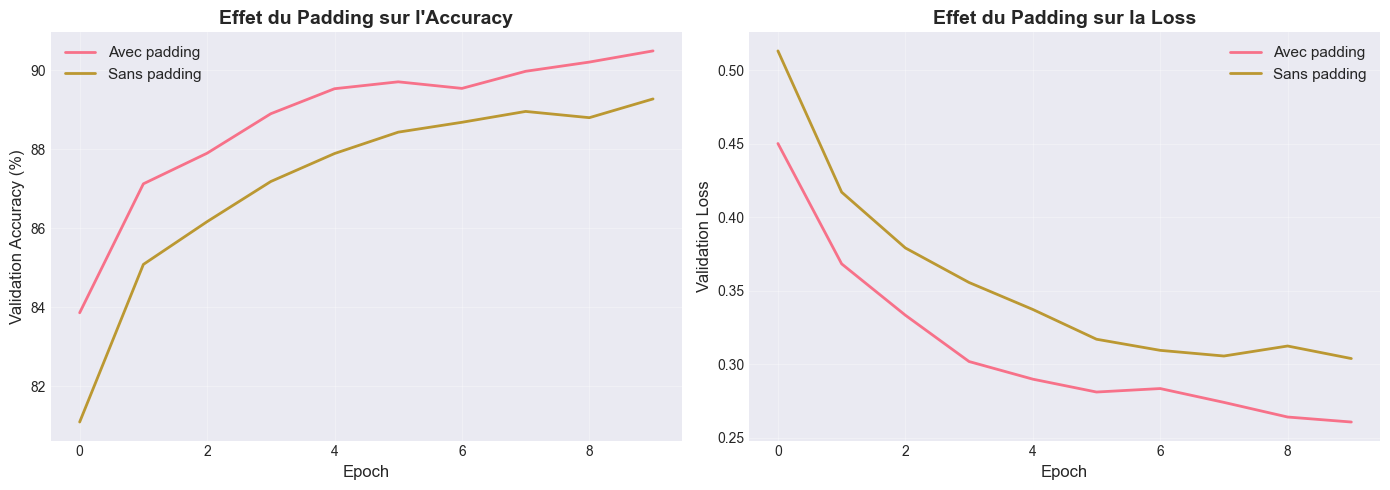

In [47]:
# Visualisation effet padding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_with_pad['val_acc'], label='Avec padding', linewidth=2)
axes[0].plot(history_no_pad['val_acc'], label='Sans padding', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Effet du Padding sur l\'Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_with_pad['val_loss'], label='Avec padding', linewidth=2)
axes[1].plot(history_no_pad['val_loss'], label='Sans padding', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Effet du Padding sur la Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/padding_effect.png', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
# Expérience 2: Max Pooling vs Average Pooling
class LeNetAvgPool(nn.Module):
    def __init__(self):
        super(LeNetAvgPool, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)  # Average pooling
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("=== Expérience 2: Max Pooling vs Average Pooling ===")
model_maxpool = LeNet().to(device)
model_avgpool = LeNetAvgPool().to(device)

print("\nMax Pooling:")
history_maxpool = train_model(model_maxpool, train_loader, val_loader, num_epochs=10)

print("\nAverage Pooling:")
history_avgpool = train_model(model_avgpool, train_loader, val_loader, num_epochs=10)

=== Expérience 2: Max Pooling vs Average Pooling ===

Max Pooling:


KeyboardInterrupt: 

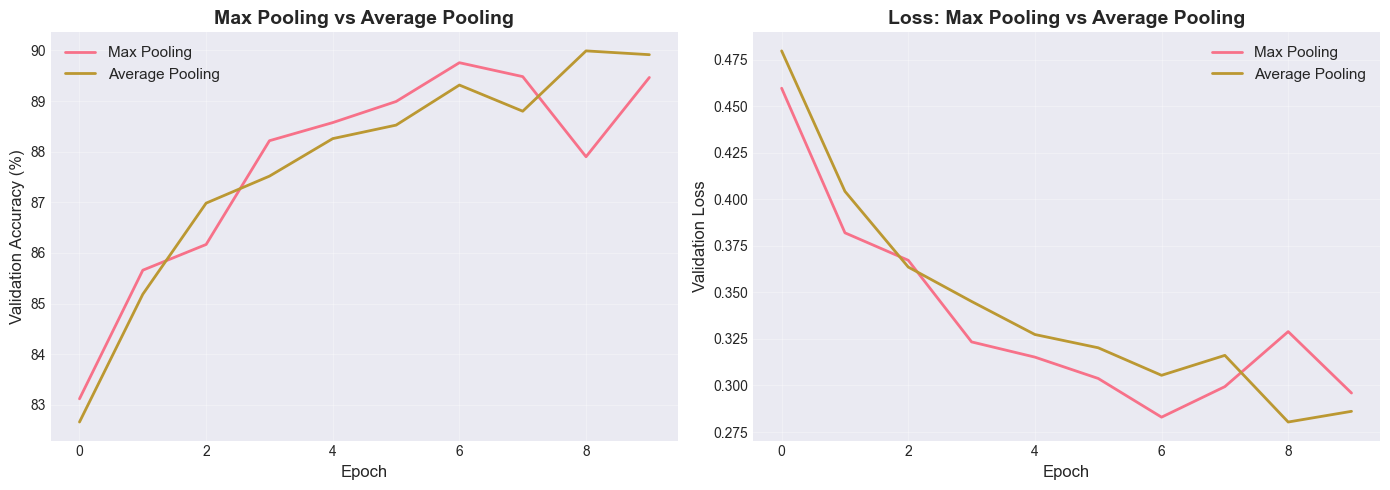

In [ ]:
# Visualisation pooling comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_maxpool['val_acc'], label='Max Pooling', linewidth=2)
axes[0].plot(history_avgpool['val_acc'], label='Average Pooling', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Max Pooling vs Average Pooling', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_maxpool['val_loss'], label='Max Pooling', linewidth=2)
axes[1].plot(history_avgpool['val_loss'], label='Average Pooling', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Loss: Max Pooling vs Average Pooling', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/pooling_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Expérience 3: Nombre de filtres
class LeNetMoreFilters(nn.Module):
    def __init__(self):
        super(LeNetMoreFilters, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)  # Plus de filtres
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("=== Expérience 3: Nombre de filtres ===")
model_base = LeNet().to(device)
model_more_filters = LeNetMoreFilters().to(device)

print(f"Paramètres modèle base : {sum(p.numel() for p in model_base.parameters()):,}")
print(f"Paramètres modèle plus de filtres : {sum(p.numel() for p in model_more_filters.parameters()):,}")

print("\nModèle base (6, 16 filtres):")
history_base = train_model(model_base, train_loader, val_loader, num_epochs=10)

print("\nModèle plus de filtres (32, 64 filtres):")
history_more = train_model(model_more_filters, train_loader, val_loader, num_epochs=10)

=== Expérience 3: Nombre de filtres ===
Paramètres modèle base : 61,706
Paramètres modèle plus de filtres : 255,230

Modèle base (6, 16 filtres):
Epoch [5/10], Train Loss: 0.2873, Train Acc: 89.35%, Val Loss: 0.3145, Val Acc: 88.42%
Epoch [10/10], Train Loss: 0.2194, Train Acc: 91.81%, Val Loss: 0.2754, Val Acc: 89.93%

Modèle plus de filtres (32, 64 filtres):
Epoch [5/10], Train Loss: 0.2120, Train Acc: 92.20%, Val Loss: 0.2630, Val Acc: 91.05%
Epoch [10/10], Train Loss: 0.1162, Train Acc: 95.58%, Val Loss: 0.2768, Val Acc: 91.36%


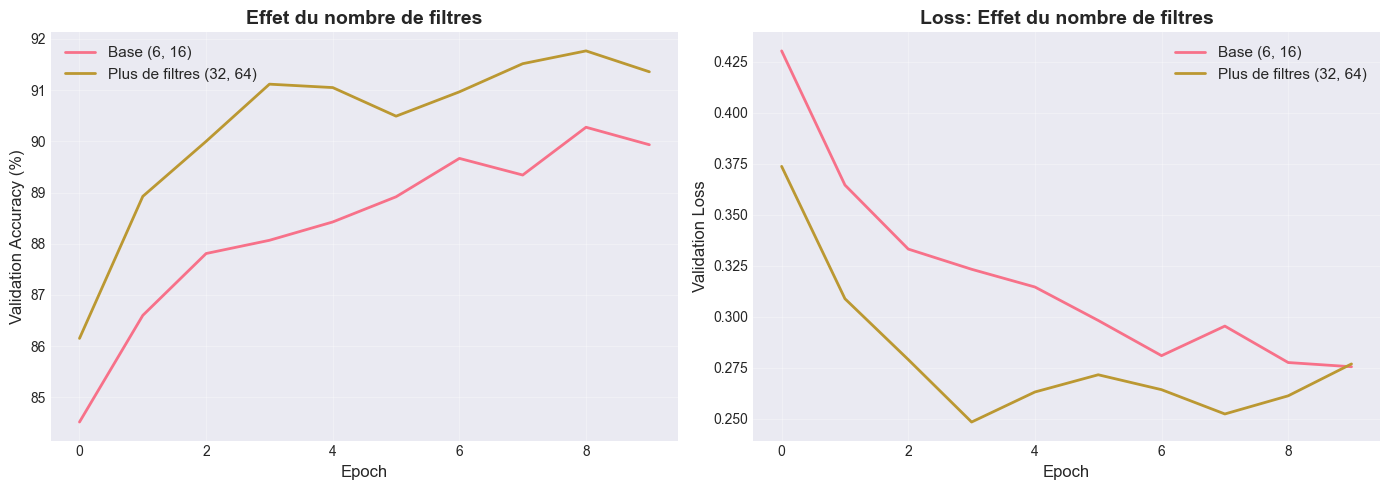

In [49]:
# Visualisation nombre de filtres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_base['val_acc'], label='Base (6, 16)', linewidth=2)
axes[0].plot(history_more['val_acc'], label='Plus de filtres (32, 64)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Effet du nombre de filtres', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_base['val_loss'], label='Base (6, 16)', linewidth=2)
axes[1].plot(history_more['val_loss'], label='Plus de filtres (32, 64)', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Loss: Effet du nombre de filtres', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/filters_effect.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Visualisation des feature maps et filtres

In [50]:
# Entraînement du modèle final pour visualisation
final_model = LeNet().to(device)
print("=== Entraînement du modèle final ===")
final_history = train_model(final_model, train_loader, val_loader, num_epochs=15)

=== Entraînement du modèle final ===
Epoch [5/15], Train Loss: 0.2871, Train Acc: 89.24%, Val Loss: 0.3154, Val Acc: 88.78%
Epoch [10/15], Train Loss: 0.2147, Train Acc: 91.89%, Val Loss: 0.2828, Val Acc: 89.89%
Epoch [15/15], Train Loss: 0.1665, Train Acc: 93.73%, Val Loss: 0.2954, Val Acc: 90.08%


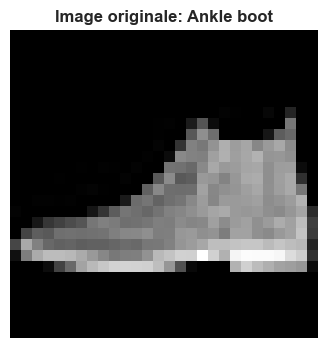

In [51]:
# Fonction pour extraire les feature maps
def get_feature_maps(model, image, layer_name):
    """
    Extrait les feature maps d'une couche spécifique.
    """
    x = image.unsqueeze(0).to(device)
    
    if layer_name == 'conv1':
        x = model.conv1(x)
    elif layer_name == 'pool1':
        x = model.pool1(F.relu(model.conv1(x)))
    elif layer_name == 'conv2':
        x = model.pool1(F.relu(model.conv1(x)))
        x = model.conv2(x)
    elif layer_name == 'pool2':
        x = model.pool1(F.relu(model.conv1(x)))
        x = model.pool2(F.relu(model.conv2(x)))
    
    return x.squeeze().detach().cpu()

# Sélection d'une image de test
test_image, test_label = test_dataset[0]

# Visualisation de l'image originale
plt.figure(figsize=(4, 4))
plt.imshow(test_image.squeeze(), cmap='gray')
plt.title(f'Image originale: {class_names[test_label]}', fontweight='bold')
plt.axis('off')
plt.savefig('figures/original_image.png', dpi=300, bbox_inches='tight')
plt.show()

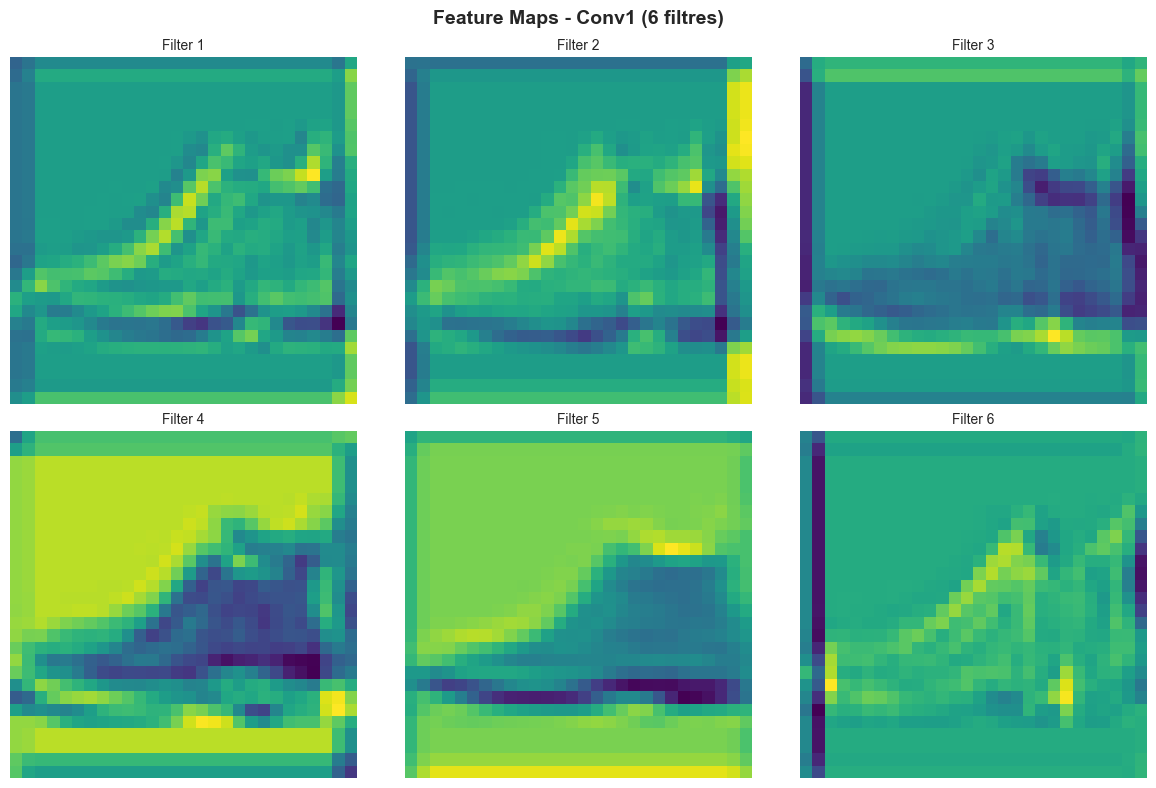

In [52]:
# Visualisation des feature maps de la première couche
feature_maps_conv1 = get_feature_maps(final_model, test_image, 'conv1')

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(min(6, feature_maps_conv1.shape[0])):
    axes[i].imshow(feature_maps_conv1[i].detach().numpy(), cmap='viridis')
    axes[i].set_title(f'Filter {i+1}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Feature Maps - Conv1 (6 filtres)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/feature_maps_conv1.png', dpi=300, bbox_inches='tight')
plt.show()

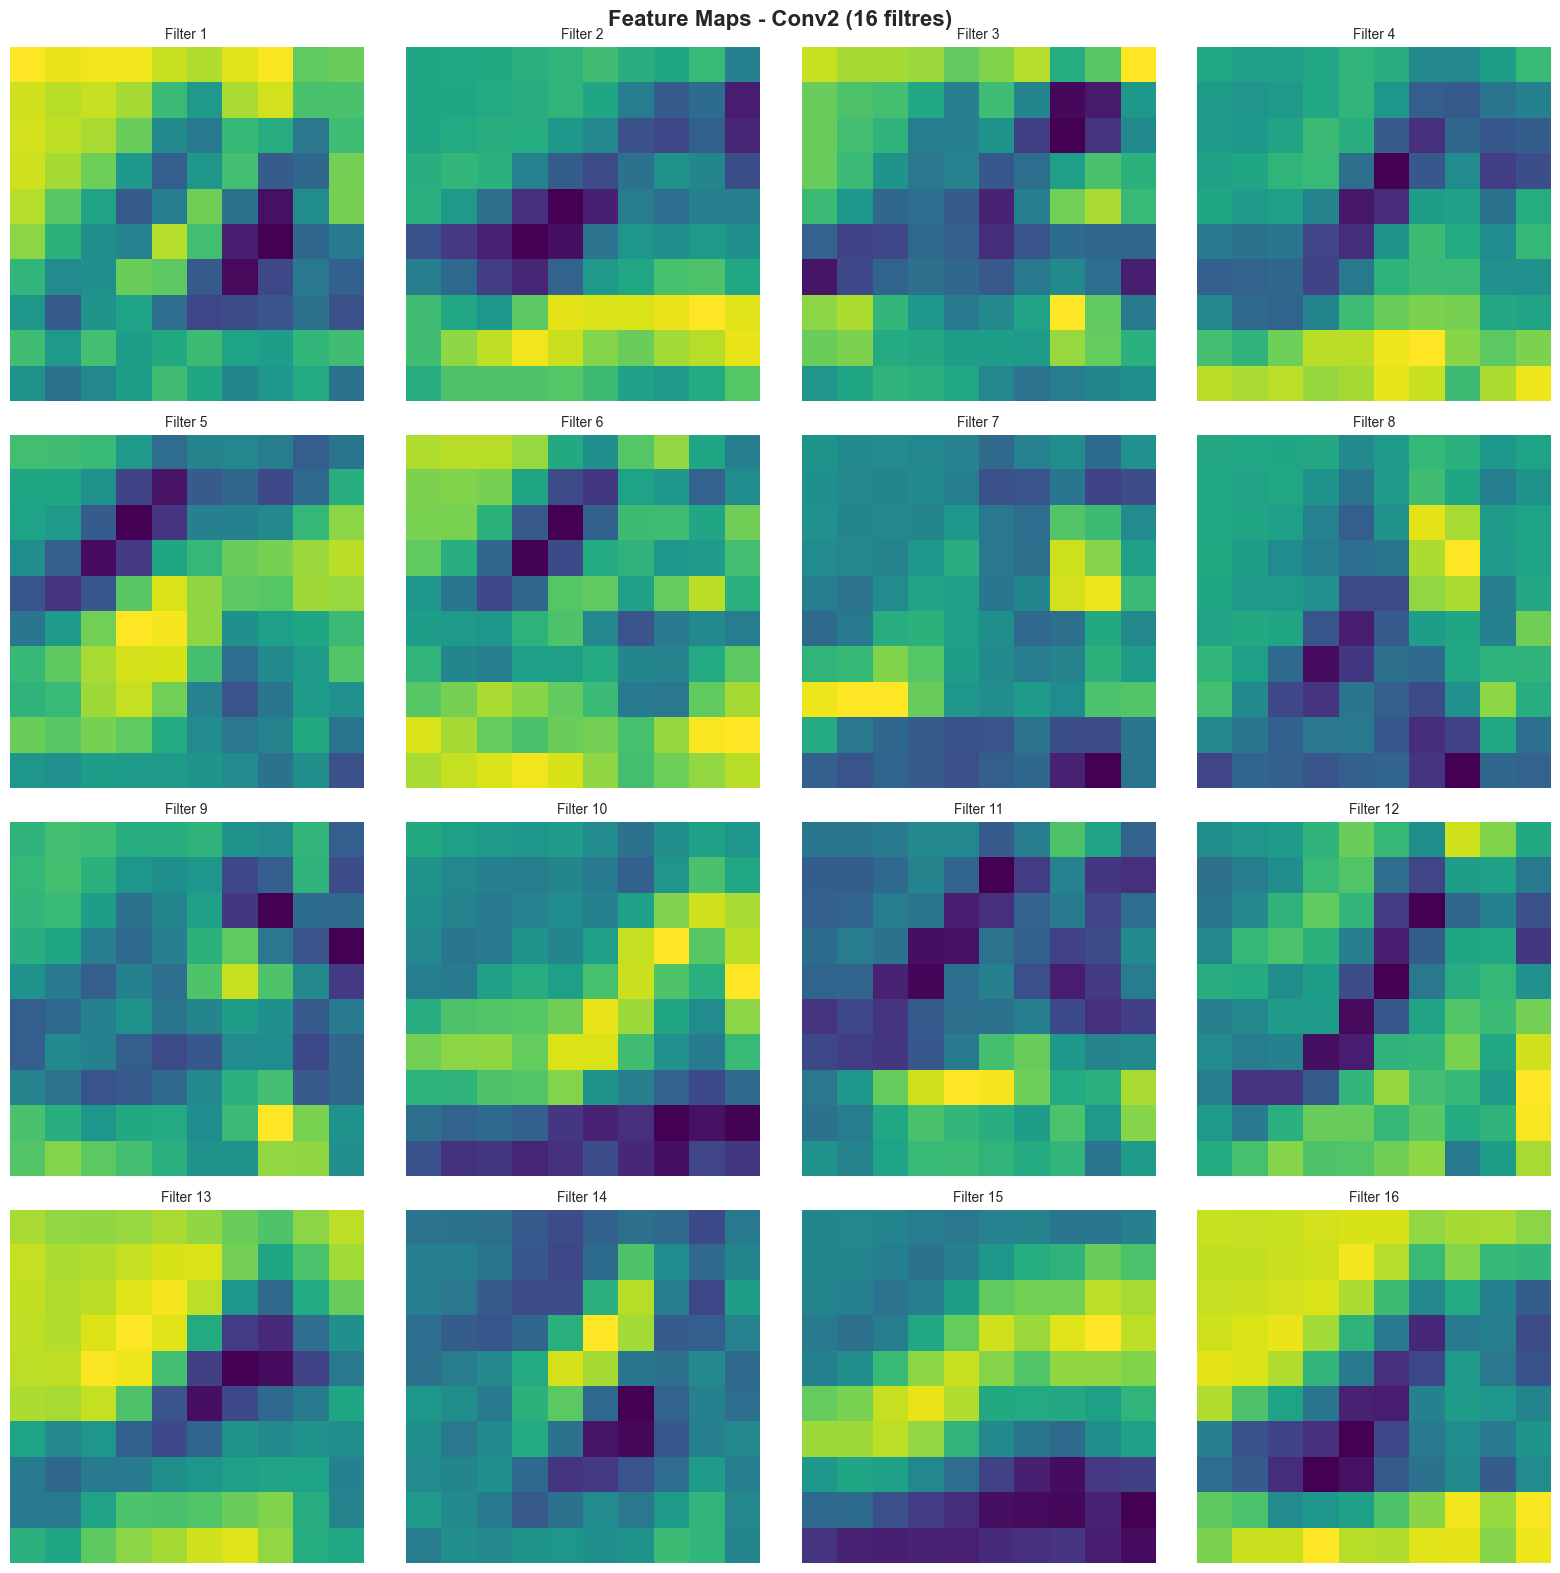

In [53]:
# Visualisation des feature maps de la deuxième couche
feature_maps_conv2 = get_feature_maps(final_model, test_image, 'conv2')

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i in range(min(16, feature_maps_conv2.shape[0])):
    axes[i].imshow(feature_maps_conv2[i].detach().numpy(), cmap='viridis')
    axes[i].set_title(f'Filter {i+1}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Feature Maps - Conv2 (16 filtres)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/feature_maps_conv2.png', dpi=300, bbox_inches='tight')
plt.show()

Figure sauvegardée : part2_cnn/figures\filters_conv1.png


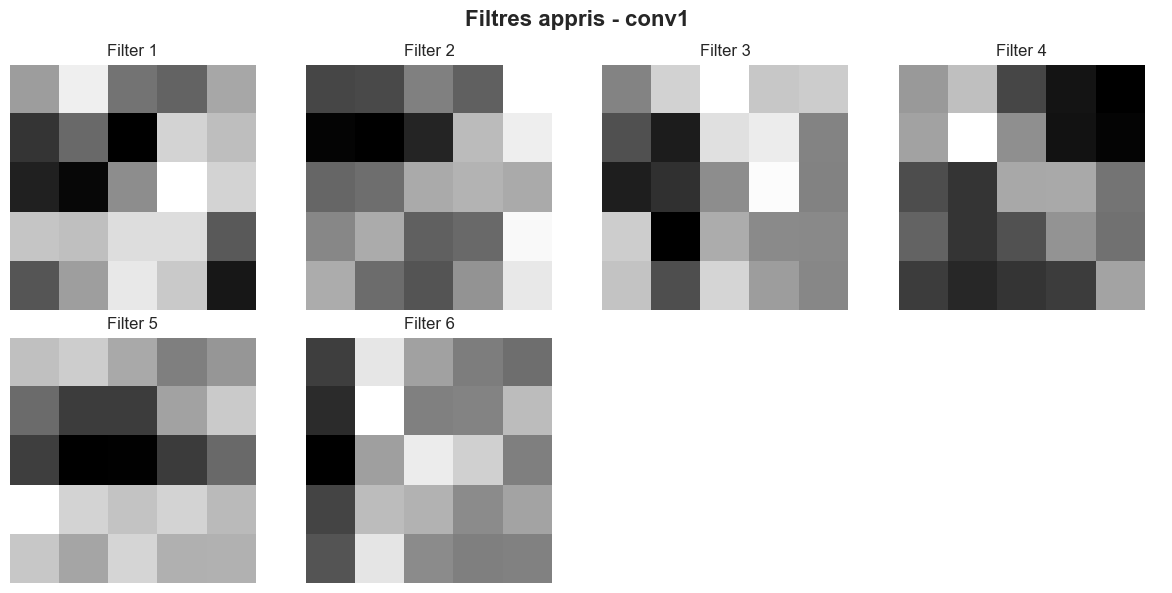

Figure sauvegardée : part2_cnn/figures\filters_conv2.png


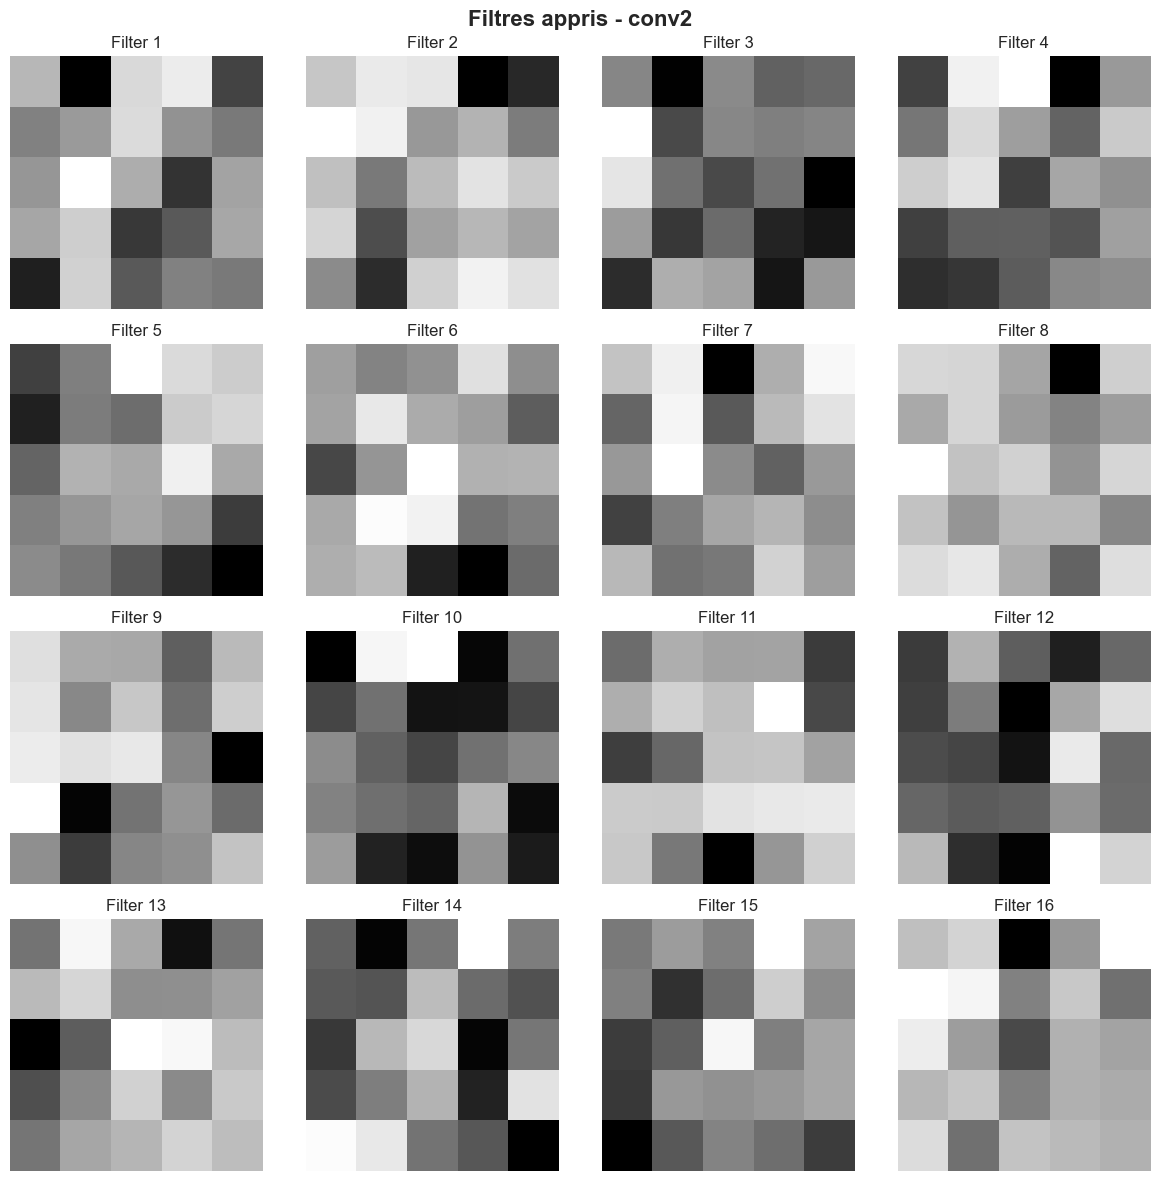

In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt

def visualize_filters(model, layer_name, save_dir="part2_cnn/figures"):
    """
    Visualise les filtres appris d'une couche convolutionnelle.
    """

    # Création automatique du dossier
    os.makedirs(save_dir, exist_ok=True)

    # Récupération des poids
    if layer_name == 'conv1':
        filters = model.conv1.weight.detach().cpu()
    elif layer_name == 'conv2':
        filters = model.conv2.weight.detach().cpu()
    else:
        raise ValueError("layer_name doit être 'conv1' ou 'conv2'")

    n_filters = filters.shape[0]
    n_cols = 4
    n_rows = int(np.ceil(n_filters / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(12, 3 * n_rows)
    )

    # Cas particulier : un seul filtre
    if n_filters == 1:
        axes = [axes]
    else:
        axes = np.array(axes).flatten()

    for i in range(n_filters):

        # Images en niveaux de gris
        if filters.shape[1] == 1:
            img = filters[i, 0]
            axes[i].imshow(img, cmap='gray')

        # Images RGB ou multi-canaux
        else:
            img = filters[i]

            # Normalisation pour affichage
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)

            if img.shape[0] == 3:
                axes[i].imshow(img.permute(1, 2, 0))
            else:
                axes[i].imshow(img[0], cmap='gray')

        axes[i].set_title(f'Filter {i+1}')
        axes[i].axis('off')

    # Supprimer les cases vides
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')

    plt.suptitle(
        f'Filtres appris - {layer_name}',
        fontsize=16,
        fontweight='bold'
    )

    plt.tight_layout()

    save_path = os.path.join(
        save_dir,
        f'filters_{layer_name}.png'
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    print(f"Figure sauvegardée : {save_path}")

    plt.show()


# Utilisation
visualize_filters(final_model, 'conv1')
visualize_filters(final_model, 'conv2')

# Visualisation des filtres appris
def visualize_filters(model, layer_name):
    """
    Visualise les filtres d'une couche convolutionnelle.
    """
    if layer_name == 'conv1':
        filters = model.conv1.weight.data.cpu()
    elif layer_name == 'conv2':
        filters = model.conv2.weight.data.cpu()
    else:
        return None
    
    n_filters = filters.shape[0]
    fig, axes = plt.subplots(int(np.ceil(n_filters/4)), 4, figsize=(12, 3*int(np.ceil(n_filters/4))))
    axes = axes.flatten()
    
    for i in range(n_filters):
        if filters.shape[1] == 1:  # Grayscale
            axes[i].imshow(filters[i, 0], cmap='gray')
        else:  # RGB
            axes[i].imshow(filters[i].permute(1, 2, 0))
        axes[i].set_title(f'Filter {i+1}', fontsize=10)
        axes[i].axis('off')
    
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Filtres appris - {layer_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/filters_{layer_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_filters(final_model, 'conv1')

In [ ]:
# Visualisation des filtres appris
def visualize_filters(model, layer_name):
    """
    Visualise les filtres d'une couche convolutionnelle.
    """
    if layer_name == 'conv1':
        filters = model.conv1.weight.data.cpu()
    elif layer_name == 'conv2':
        filters = model.conv2.weight.data.cpu()
    else:
        return None
    
    n_filters = filters.shape[0]
    fig, axes = plt.subplots(int(np.ceil(n_filters/4)), 4, figsize=(12, 3*int(np.ceil(n_filters/4))))
    axes = axes.flatten()
    
    for i in range(n_filters):
        if filters.shape[1] == 1:  # Grayscale
            axes[i].imshow(filters[i, 0], cmap='gray')
        else:  # RGB
            axes[i].imshow(filters[i].permute(1, 2, 0))
        axes[i].set_title(f'Filter {i+1}', fontsize=10)
        axes[i].axis('off')
    
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Filtres appris - {layer_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/filters_{layer_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_filters(final_model, 'conv1')

In [ ]:
# Visualisation des filtres appris
def visualize_filters(model, layer_name):
    """
    Visualise les filtres d'une couche convolutionnelle.
    """
    if layer_name == 'conv1':
        filters = model.conv1.weight.data.cpu()
    elif layer_name == 'conv2':
        filters = model.conv2.weight.data.cpu()
    else:
        return None
    
    n_filters = filters.shape[0]
    fig, axes = plt.subplots(int(np.ceil(n_filters/4)), 4, figsize=(12, 3*int(np.ceil(n_filters/4))))
    axes = axes.flatten()
    
    for i in range(n_filters):
        if filters.shape[1] == 1:  # Grayscale
            axes[i].imshow(filters[i, 0], cmap='gray')
        else:  # RGB
            axes[i].imshow(filters[i].permute(1, 2, 0))
        axes[i].set_title(f'Filter {i+1}', fontsize=10)
        axes[i].axis('off')
    
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Filtres appris - {layer_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/filters_{layer_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_filters(final_model, 'conv1')

In [ ]:
# Visualisation des filtres appris
def visualize_filters(model, layer_name):
    """
    Visualise les filtres d'une couche convolutionnelle.
    """
    if layer_name == 'conv1':
        filters = model.conv1.weight.data.cpu()
    elif layer_name == 'conv2':
        filters = model.conv2.weight.data.cpu()
    else:
        return None
    
    n_filters = filters.shape[0]
    fig, axes = plt.subplots(int(np.ceil(n_filters/4)), 4, figsize=(12, 3*int(np.ceil(n_filters/4))))
    axes = axes.flatten()
    
    for i in range(n_filters):
        if filters.shape[1] == 1:  # Grayscale
            axes[i].imshow(filters[i, 0], cmap='gray')
        else:  # RGB
            axes[i].imshow(filters[i].permute(1, 2, 0))
        axes[i].set_title(f'Filter {i+1}', fontsize=10)
        axes[i].axis('off')
    
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Filtres appris - {layer_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/filters_{layer_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_filters(final_model, 'conv1')

In [ ]:
# Visualisation des filtres appris
def visualize_filters(model, layer_name):
    """
    Visualise les filtres d'une couche convolutionnelle.
    """
    if layer_name == 'conv1':
        filters = model.conv1.weight.data.cpu()
    elif layer_name == 'conv2':
        filters = model.conv2.weight.data.cpu()
    else:
        return None
    
    n_filters = filters.shape[0]
    fig, axes = plt.subplots(int(np.ceil(n_filters/4)), 4, figsize=(12, 3*int(np.ceil(n_filters/4))))
    axes = axes.flatten()
    
    for i in range(n_filters):
        if filters.shape[1] == 1:  # Grayscale
            axes[i].imshow(filters[i, 0], cmap='gray')
        else:  # RGB
            axes[i].imshow(filters[i].permute(1, 2, 0))
        axes[i].set_title(f'Filter {i+1}', fontsize=10)
        axes[i].axis('off')
    
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'Filtres appris - {layer_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'figures/filters_{layer_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

visualize_filters(final_model, 'conv1')

## 10. Évaluation du modèle

In [ ]:
# Évaluation sur l'ensemble de test
def evaluate_model(model, test_loader, device):
    """
    Évalue le modèle sur l'ensemble de test.
    """
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    return np.array(all_predictions), np.array(all_labels)

predictions, true_labels = evaluate_model(final_model, test_loader, device)

In [ ]:
# Matrice de confusion
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_title('Matrice de Confusion - CNN', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=12)
ax.set_ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Matrice de confusion
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_title('Matrice de Confusion - CNN', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=12)
ax.set_ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('part2_cnn/figures/confusion_matrix_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Rapport de classification détaillé
from sklearn.metrics import classification_report
print("=== Rapport de classification détaillé ===")
print(classification_report(true_labels, predictions, target_names=class_names))

In [ ]:
# Visualisation des erreurs
errors = predictions != true_labels
error_indices = np.where(errors)[0]

print(f"Nombre total d'erreurs : {len(error_indices)} sur {len(true_labels)}")
print(f"Taux d'erreur : {len(error_indices)/len(true_labels)*100:.2f}%")

# Affichage de quelques erreurs
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, idx in enumerate(error_indices[:15]):
    img, true_label = test_dataset[idx]
    pred_label = predictions[idx]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'Vrai: {class_names[true_label]}\nPred: {class_names[pred_label]}', 
                      fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle('Exemples d\'erreurs de classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/error_examples.png', dpi=300, bbox_inches='tight')
plt.show()

# Matrice de confusion
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_title('Matrice de Confusion - CNN', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=12)
ax.set_ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

# Matrice de confusion
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_title('Matrice de Confusion - CNN', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=12)
ax.set_ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

# Matrice de confusion
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_title('Matrice de Confusion - CNN', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=12)
ax.set_ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

# Matrice de confusion
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Nombre d\'échantillons'})
ax.set_title('Matrice de Confusion - CNN', fontsize=14, fontweight='bold')
ax.set_xlabel('Prédit', fontsize=12)
ax.set_ylabel('Réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusion de la Partie II

Cette partie a démontré la supériorité des CNN sur les MLP pour la classification d'images. Les résultats expérimentaux sur Fashion-MNIST confirment que l'architecture CNN, avec ses propriétés de localité, partage de poids et hiérarchie de features, est naturellement adaptée aux données visuelles.

Les points clés retenus :
1. **Localité et partage des poids** : Fondamentaux pour l'efficacité des CNN
2. **Padding et Stride** : Contrôlent les dimensions et le réceptive field
3. **Pooling** : Réduit la dimension tout en préservant l'information
4. **Nombre de filtres** : Influence la capacité représentationnelle
5. **Supériorité sur MLP** : Meilleure performance avec moins de paramètres

La partie suivante explorera comment les architectures récurrentes (RNN, LSTM, GRU, Seq2Seq) s'adaptent aux données séquentielles.